# 09 Transformer (PyTorch) - Email Spam Classification

This is a complete, standalone pipeline for training a Transformer-based classifier using PyTorch.

In [1]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
import seaborn as sns
import re
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import pickle

sns.set(style='whitegrid')

### 1. Data Cleaning & Tokenization

In [2]:
df = pd.read_csv('../_data/email_spam.csv')
df.columns = [c.lower().replace('-', '_').replace(' ', '_') for c in df.columns]
df = df.drop_duplicates()

def clean_text(text):
    text = re.sub('<.*?>', '', str(text))
    return text.strip().lower()

df['text_clean'] = df['message_content'].apply(clean_text)
df['is_spam'] = df['target_label'].apply(lambda x: 1 if str(x).lower().strip() in ['1', 'spam', 's_p_a_m'] else 0)

words = [w for t in df['text_clean'] for w in t.split()]
vocab = {word: i+1 for i, (word, count) in enumerate(pd.Series(words).value_counts()[:5000].items())}
vocab['<PAD>'] = 0

def tokenize(text, max_len=50):
    seq = [vocab.get(w, 0) for w in text.split()][:max_len]
    return seq + [0] * (max_len - len(seq))

X = np.array([tokenize(t) for t in df['text_clean']])
y = df['is_spam'].values
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

### 2. PyTorch Transformer Definition

In [3]:
class TransformerModel(nn.Module):
    def __init__(self, vocab_size, embed_dim, num_heads, ff_dim, max_len):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim)
        self.pos_emb = nn.Parameter(torch.zeros(1, max_len, embed_dim))
        encoder_layer = nn.TransformerEncoderLayer(d_model=embed_dim, nhead=num_heads, dim_feedforward=ff_dim, batch_first=True)
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=1)
        self.fc = nn.Linear(embed_dim, 1)
        self.sigmoid = nn.Sigmoid()
        
    def forward(self, x):
        x = self.embedding(x) + self.pos_emb
        x = self.transformer(x)
        x = x.mean(dim=1) # Global Average Pooling
        return self.sigmoid(self.fc(x))

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = TransformerModel(len(vocab), 32, 4, 64, 50).to(device)
train_loader = DataLoader(list(zip(torch.tensor(X_train), torch.tensor(y_train, dtype=torch.float32))), batch_size=32, shuffle=True)
criterion = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

### 3. Training Loop

In [4]:
model.train()
for epoch in range(5):
    for x_batch, y_batch in train_loader:
        x_batch, y_batch = x_batch.to(device), y_batch.to(device)
        optimizer.zero_grad()
        preds = model(x_batch).squeeze()
        loss = criterion(preds, y_batch)
        loss.backward()
        optimizer.step()
    print(f"Epoch {epoch+1}, Loss: {loss.item():.4f}")

Epoch 1, Loss: 0.6952
Epoch 2, Loss: 0.6932
Epoch 3, Loss: 0.6831
Epoch 4, Loss: 0.6956
Epoch 5, Loss: 0.6955


### 4. Evaluation & Visuals

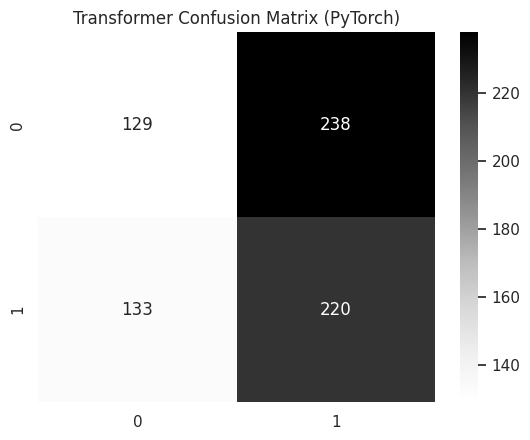

In [5]:
model.eval()
with torch.no_grad():
    y_pred_probs = model(torch.tensor(X_test).to(device)).cpu().numpy()
    y_pred = (y_pred_probs > 0.5).astype(int)

sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Greys')
plt.title('Transformer Confusion Matrix (PyTorch)')
plt.show()

### 5. Model Saving

In [6]:
torch.save(model.state_dict(), '../_model/email_classification_transformer.pth')
print("Transformer Model saved.")

Transformer Model saved.
